# Publication Visualizations

In [1]:
#| label: setup
#| include: false
from pathlib import Path
import shutil
import subprocess
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text
from IPython.display import Image, display

_candidates = [Path("."), Path("notebooks")]
DATA_DIR = next(
    (
        path
        for path in _candidates
        if (path / "publication_results_long.csv").exists()
    ),
    None,
)

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find publication_results_long.csv in the current "
        "directory or notebooks/."
    )

results = pd.read_csv(DATA_DIR / "publication_results_long.csv")
independence_curves = pd.read_csv(
    DATA_DIR / "independence_curves_all.csv"
)
pca_variance = pd.read_csv(
    DATA_DIR / "pca_variance_all.csv"
)

latent_paths = {
    "mlv": DATA_DIR / "latent_correlation_mlv.csv",
    "lovb": DATA_DIR / "latent_correlation_lovb.csv",
    "au": DATA_DIR / "latent_correlation_au.csv",
}

LEAGUES = ("mlv", "lovb", "au")

LEAGUE_DISPLAY_LABELS = {
    "mlv": "MLV",
    "lovb": "LOVB Pro",
    "au": "AU Pro",
}

LATEST_YEAR = {
    "mlv": 2026,
    "lovb": 2026,
    "au": 2025,
}

FAMILY_LABELS = {
    "conventional": "Conventional",
    "advanced": "Advanced",
    "evollve": "Evollve",
}

FAMILY_COLORS = {
    "conventional": "#3569A8",
    "advanced": "#C85454",
    "evollve": "#398B68",
}

FAMILY_MARKERS = {
    "conventional": "o",
    "advanced": "D",
    "evollve": "^",
}

RELIABILITY_FAMILY_GROUP = {
    "conventional": "conventional",
    "advanced": "advanced",
    "evollve": "advanced",
}

RELIABILITY_DISPLAY_FAMILIES = (
    "conventional",
    "advanced",
)

PCA_LABEL_OFFSETS = {
    "mlv": (3, 4),
    "lovb": (3, -15),
    "au": (3, 4),
}


def publication_style():
    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": 13.5,
        "axes.titlesize": 16,
        "axes.labelsize": 15,
        "xtick.labelsize": 12.5,
        "ytick.labelsize": 12.5,
        "legend.fontsize": 12.5,
        "figure.dpi": 140,
        "savefig.dpi": 320,
        "pdf.fonttype": 42,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })


def separate_remaining_label_overlaps(ax, texts):
    figure = ax.figure
    figure.canvas.draw()
    renderer = figure.canvas.get_renderer()
    axes_box = ax.get_window_extent(renderer)

    occupied = []
    offsets = [(0.0, 0.0)]
    step = 4.0

    for radius in range(1, 31):
        ring = [
            (dx * step, dy * step)
            for dx in range(-radius, radius + 1)
            for dy in range(-radius, radius + 1)
            if max(abs(dx), abs(dy)) == radius
        ]

        ring.sort(
            key=lambda offset: (
                offset[0] ** 2 + offset[1] ** 2,
                abs(offset[0]),
                abs(offset[1]),
                offset[1] < 0,
                offset[0] < 0,
            )
        )

        offsets.extend(ring)

    for text in texts:
        base_box = (
            text.get_window_extent(renderer)
            .expanded(1.02, 1.10)
        )

        base_position = np.asarray(
            text.get_transform().transform(text.get_position())
        )

        for dx, dy in offsets:
            candidate = base_box.translated(dx, dy)

            inside = (
                candidate.x0 >= axes_box.x0
                and candidate.x1 <= axes_box.x1
                and candidate.y0 >= axes_box.y0
                and candidate.y1 <= axes_box.y1
            )

            if (
                inside
                and not any(
                    candidate.overlaps(previous)
                    for previous in occupied
                )
            ):
                if dx or dy:
                    text.set_position(
                        text.get_transform()
                        .inverted()
                        .transform(
                            base_position
                            + np.asarray((dx, dy))
                        )
                    )

                occupied.append(candidate)
                break

        else:
            raise RuntimeError(
                "Unable to place all reliability labels without overlap"
            )


def label_points(ax, frame, x, y, *, fontsize):
    finite = (
        frame.dropna(subset=[x, y])
        .sort_values([x, y, "metric"])
    )

    texts = [
        ax.text(
            getattr(row, x),
            getattr(row, y),
            row.plot_label,
            fontsize=fontsize,
            ha="center",
            va="center",
            color="#202020",
            zorder=4,
        )
        for row in finite.itertuples(index=False)
    ]

    random_state = np.random.get_state()
    np.random.seed(42)

    try:
        adjust_text(
            texts,
            x=finite[x].to_numpy(float),
            y=finite[y].to_numpy(float),
            ax=ax,
            prevent_crossings=True,
            ensure_inside_axes=True,
            expand=(1.35, 1.65),
            force_text=(0.70, 1.00),
            force_static=(0.30, 0.50),
            force_pull=(0.008, 0.008),
            max_move=(24, 28),
            explode_radius="auto",
            iter_lim=2000,
        )
    finally:
        np.random.set_state(random_state)

    separate_remaining_label_overlaps(ax, texts)

    for text, row in zip(
        texts,
        finite.itertuples(index=False),
    ):
        point = np.asarray(
            ax.transData.transform(
                (getattr(row, x), getattr(row, y))
            )
        )

        label = np.asarray(
            ax.transData.transform(text.get_position())
        )

        if np.linalg.norm(point - label) >= 9:
            ax.annotate(
                "",
                xy=(getattr(row, x), getattr(row, y)),
                xytext=text.get_position(),
                textcoords="data",
                arrowprops={
                    "arrowstyle": "-",
                    "color": "#777777",
                    "linewidth": .45,
                    "alpha": .65,
                },
                zorder=2,
            )

    return texts


def plot_reliability_panel(
    ax,
    frame,
    league,
    *,
    label_fontsize=11.5,
):
    reliability_group = frame["family"].map(
        RELIABILITY_FAMILY_GROUP
    )

    for family in RELIABILITY_DISPLAY_FAMILIES:
        subset = frame.loc[
            reliability_group.eq(family)
        ].dropna(
            subset=[
                "Discrimination",
                "Stability_corrected",
            ]
        )

        ax.scatter(
            subset["Discrimination"],
            subset["Stability_corrected"],
            color=FAMILY_COLORS[family],
            marker=FAMILY_MARKERS[family],
            s=28,
            linewidth=.5,
            edgecolor="white",
            label=FAMILY_LABELS[family],
            zorder=3,
        )

    missing = frame.loc[
        frame["Stability_corrected"].isna(),
        "display_label",
    ].tolist()

    if missing:
        ax.text(
            .02,
            .02,
            "Stability unavailable: " + ", ".join(missing),
            transform=ax.transAxes,
            fontsize=9,
            color="#555",
            va="bottom",
        )

    ax.axhline(
        0,
        color="#9a9a9a",
        linewidth=.6,
        linestyle="--",
        zorder=0,
    )

    ax.axvline(
        0,
        color="#9a9a9a",
        linewidth=.6,
        linestyle="--",
        zorder=0,
    )

    ax.margins(x=.08, y=.08)

    ax.grid(
        color="#e6e6e6",
        linewidth=.5,
        zorder=0,
    )

    ax.set_title(
        LEAGUE_DISPLAY_LABELS[league],
        fontweight="semibold",
    )

    ax.set_xlabel(
        f"Discrimination ({LATEST_YEAR[league]})"
    )

    ax.set_ylabel("Corrected stability")
    ax.set_box_aspect(1)

    return label_points(
        ax,
        frame,
        "Discrimination",
        "Stability_corrected",
        fontsize=label_fontsize,
    )


def reliability_figure(league):
    publication_style()

    frame = results.loc[
        results["league"].eq(league)
    ].copy()

    fig, ax = plt.subplots(
        figsize=(8.2, 8.2),
        constrained_layout=False,
    )

    fig.subplots_adjust(
        left=.06,
        right=.985,
        bottom=.125,
        top=.935,
    )

    plot_reliability_panel(
        ax,
        frame,
        league,
        label_fontsize=11.5,
    )

    handles, labels = ax.get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        frameon=False,
        ncol=2,
        loc="lower center",
        bbox_to_anchor=(.5, .005),
        borderaxespad=0,
    )

    return fig


def highlighted_independence_metrics(league):
    league_results = results.loc[
        results["league"].eq(league),
        ["metric", "Independence"],
    ].dropna()

    ranking = league_results.sort_values(
        ["Independence", "metric"],
        ascending=[False, True],
    )

    return ranking.head(5)["metric"].tolist()


def plot_independence_panel(
    ax,
    league,
    *,
    legend_fontsize=11.5,
):
    league_results = results.loc[
        results["league"].eq(league)
    ].copy()

    metric_order = league_results["metric"].tolist()

    display_labels = dict(
        zip(
            league_results["metric"],
            league_results["display_label"],
        )
    )

    families = dict(
        zip(
            league_results["metric"],
            league_results["family"],
        )
    )

    highlighted = highlighted_independence_metrics(
        league
    )

    league_curves = independence_curves.loc[
        independence_curves["league"].eq(league)
    ]

    for metric in metric_order:
        curve = league_curves.loc[
            league_curves["target_metric"].eq(metric)
        ]

        if metric in highlighted:
            family = families[metric]

            ax.plot(
                curve["conditioning_size"],
                curve["independence"],
                color=FAMILY_COLORS[family],
                linewidth=2.0,
                alpha=.95,
                label=display_labels[metric],
                zorder=3,
            )

        else:
            ax.plot(
                curve["conditioning_size"],
                curve["independence"],
                color="#9aa0a6",
                linewidth=.65,
                alpha=.35,
                zorder=1,
            )

    ax.grid(
        color="#e6e6e6",
        linewidth=.5,
    )

    ax.set_title(
        LEAGUE_DISPLAY_LABELS[league],
        fontweight="semibold",
    )

    ax.set_xlabel("Metrics in conditioning set")
    ax.set_ylabel("Independence")
    ax.set_box_aspect(1)

    ax.legend(
        frameon=False,
        fontsize=legend_fontsize,
        loc="best",
    )


def independence_figure(league):
    publication_style()

    fig, ax = plt.subplots(
        figsize=(8.2, 8.2),
        constrained_layout=True,
    )

    plot_independence_panel(
        ax,
        league,
        legend_fontsize=11.5,
    )

    return fig


def meta_figure(league):
    publication_style()

    frame = results.loc[
        results["league"].eq(league)
    ].copy()

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16.4, 8.2),
        constrained_layout=False,
    )

    fig.subplots_adjust(
        left=.055,
        right=.985,
        bottom=.14,
        top=.935,
        wspace=.20,
    )

    plot_reliability_panel(
        axes[0],
        frame,
        league,
        label_fontsize=11.5,
    )

    handles, labels = axes[0].get_legend_handles_labels()

    axes[0].legend(
        handles,
        labels,
        frameon=False,
        ncol=2,
        loc="upper center",
        bbox_to_anchor=(.5, -.10),
        borderaxespad=0,
    )

    plot_independence_panel(
        axes[1],
        league,
        legend_fontsize=11.5,
    )

    return fig


def pca_component_thresholds(frame):
    cumulative = frame[
        "cumulative_variance"
    ].to_numpy(float)

    if (
        len(cumulative) == 0
        or not np.isclose(
            cumulative[-1],
            1.0,
            atol=1e-10,
        )
    ):
        raise ValueError(
            "PCA cumulative variance must end at one"
        )

    return tuple(
        int(
            np.searchsorted(
                cumulative,
                level,
                side="left",
            )
            + 1
        )
        for level in (.80, .90, .95)
    )


def pca_figure():
    publication_style()

    fig, ax = plt.subplots(
        figsize=(12.5, 4.9),
        constrained_layout=True,
    )

    colors = {
        "mlv": "#3569A8",
        "lovb": "#C85454",
        "au": "#398B68",
    }

    for league in LEAGUES:
        frame = (
            pca_variance.loc[
                pca_variance["league"].eq(league)
            ]
            .sort_values("component")
            .copy()
        )

        ax.plot(
            frame["component"],
            frame["cumulative_variance"],
            marker="o",
            markersize=3.2,
            linewidth=2,
            color=colors[league],
            label=LEAGUE_DISPLAY_LABELS[league],
        )

        for count, level in zip(
            pca_component_thresholds(frame),
            (.80, .90, .95),
        ):
            observed_level = frame.loc[
                frame["component"].eq(count),
                "cumulative_variance",
            ].iloc[0]

            ax.scatter(
                [count],
                [observed_level],
                s=28,
                color=colors[league],
                edgecolor="white",
                linewidth=.4,
            )

            label_offset = PCA_LABEL_OFFSETS[league]

            vertical_alignment = (
                "top"
                if league == "lovb"
                else "bottom"
            )

            ax.annotate(
                str(count),
                (count, observed_level),
                xytext=label_offset,
                textcoords="offset points",
                fontsize=10.5,
                va=vertical_alignment,
                color=colors[league],
                fontweight="bold",
            )

    for level in (.80, .90, .95):
        ax.axhline(
            level,
            color="#8c8c8c",
            linewidth=.7,
            linestyle="--",
        )

        ax.text(
            .4,
            level + .006,
            f"{int(level * 100)}%",
            fontsize=10,
            color="#666",
        )

    ax.set_xlim(left=.5)
    ax.set_ylim(0, 1.02)

    ax.set_xlabel(
        "Number of principal components"
    )

    ax.set_ylabel(
        "Cumulative latent variance explained"
    )

    ax.set_title(
        "PCA of posterior-mean latent metric correlations",
        fontweight="bold",
    )

    ax.grid(
        color="#e8e8e8",
        linewidth=.5,
    )

    ax.legend(frameon=False)

    return fig


DENDROGRAM_R = r'''
args <- commandArgs(trailingOnly = TRUE)

if (length(args) != 4) {
  stop("Expected: latent.csv labels.csv output.png league")
}

latent <- read.csv(
  args[[1]],
  check.names = FALSE,
  stringsAsFactors = FALSE
)

labels <- read.csv(
  args[[2]],
  stringsAsFactors = FALSE
)

metric_names <- latent[[1]]

C <- as.matrix(
  latent[, -1, drop = FALSE]
)

storage.mode(C) <- "double"

if (!identical(metric_names, colnames(C))) {
  stop("Latent matrix labels are inconsistent")
}

if (max(abs(C - t(C))) > 1e-10) {
  stop("Latent matrix is not symmetric")
}

if (max(abs(diag(C) - 1)) > 1e-10) {
  stop("Latent matrix does not have unit diagonal")
}

display_names <- setNames(
  labels$display_label,
  labels$metric
)

if (any(is.na(display_names[metric_names]))) {
  stop("Missing display labels")
}

rownames(C) <- display_names[metric_names]
colnames(C) <- display_names[metric_names]

hc <- hclust(dist(abs(C)))

png(
  args[[3]],
  width = 4480,
  height = 2048,
  res = 320,
  bg = "white"
)

par(
  mar = c(4.0, 5, 4.5, 1.5),
  las = 2,
  cex = 1.04,
  cex.main = 1.45,
  cex.lab = 1.28,
  cex.axis = 1.08
)

plot(
  hc,
  main = paste0(
    args[[4]],
    ": latent-correlation profile clustering"
  ),
  sub = "",
  xlab = "",
  ylab = "Height",
  hang = -1
)

mtext(
  "Complete linkage of Euclidean distances between rows of |C|",
  side = 1,
  line = 2.0,
  cex = 1.05,
  las = 0
)

dev.off()
'''


def dendrogram_image(league):
    rscript = shutil.which("Rscript")

    if rscript is None:
        raise RuntimeError(
            "Rscript is required to reproduce the exact "
            "publication dendrograms."
        )

    league_results = (
        results.loc[
            results["league"].eq(league),
            ["metric", "display_label"],
        ]
        .drop_duplicates()
        .copy()
    )

    with tempfile.TemporaryDirectory() as temp_dir:
        temp_dir = Path(temp_dir)

        labels_path = temp_dir / "labels.csv"
        script_path = temp_dir / "dendrogram.R"
        output_path = temp_dir / "dendrogram.png"

        league_results.to_csv(
            labels_path,
            index=False,
        )

        script_path.write_text(
            DENDROGRAM_R,
            encoding="utf-8",
        )

        subprocess.run(
            [
                rscript,
                str(script_path),
                str(latent_paths[league]),
                str(labels_path),
                str(output_path),
                LEAGUE_DISPLAY_LABELS[league],
            ],
            check=True,
            capture_output=True,
            text=True,
        )

        return Image(
            data=output_path.read_bytes(),
            format="png",
        )

findfont: Failed to find font weight semibold, now using 700.

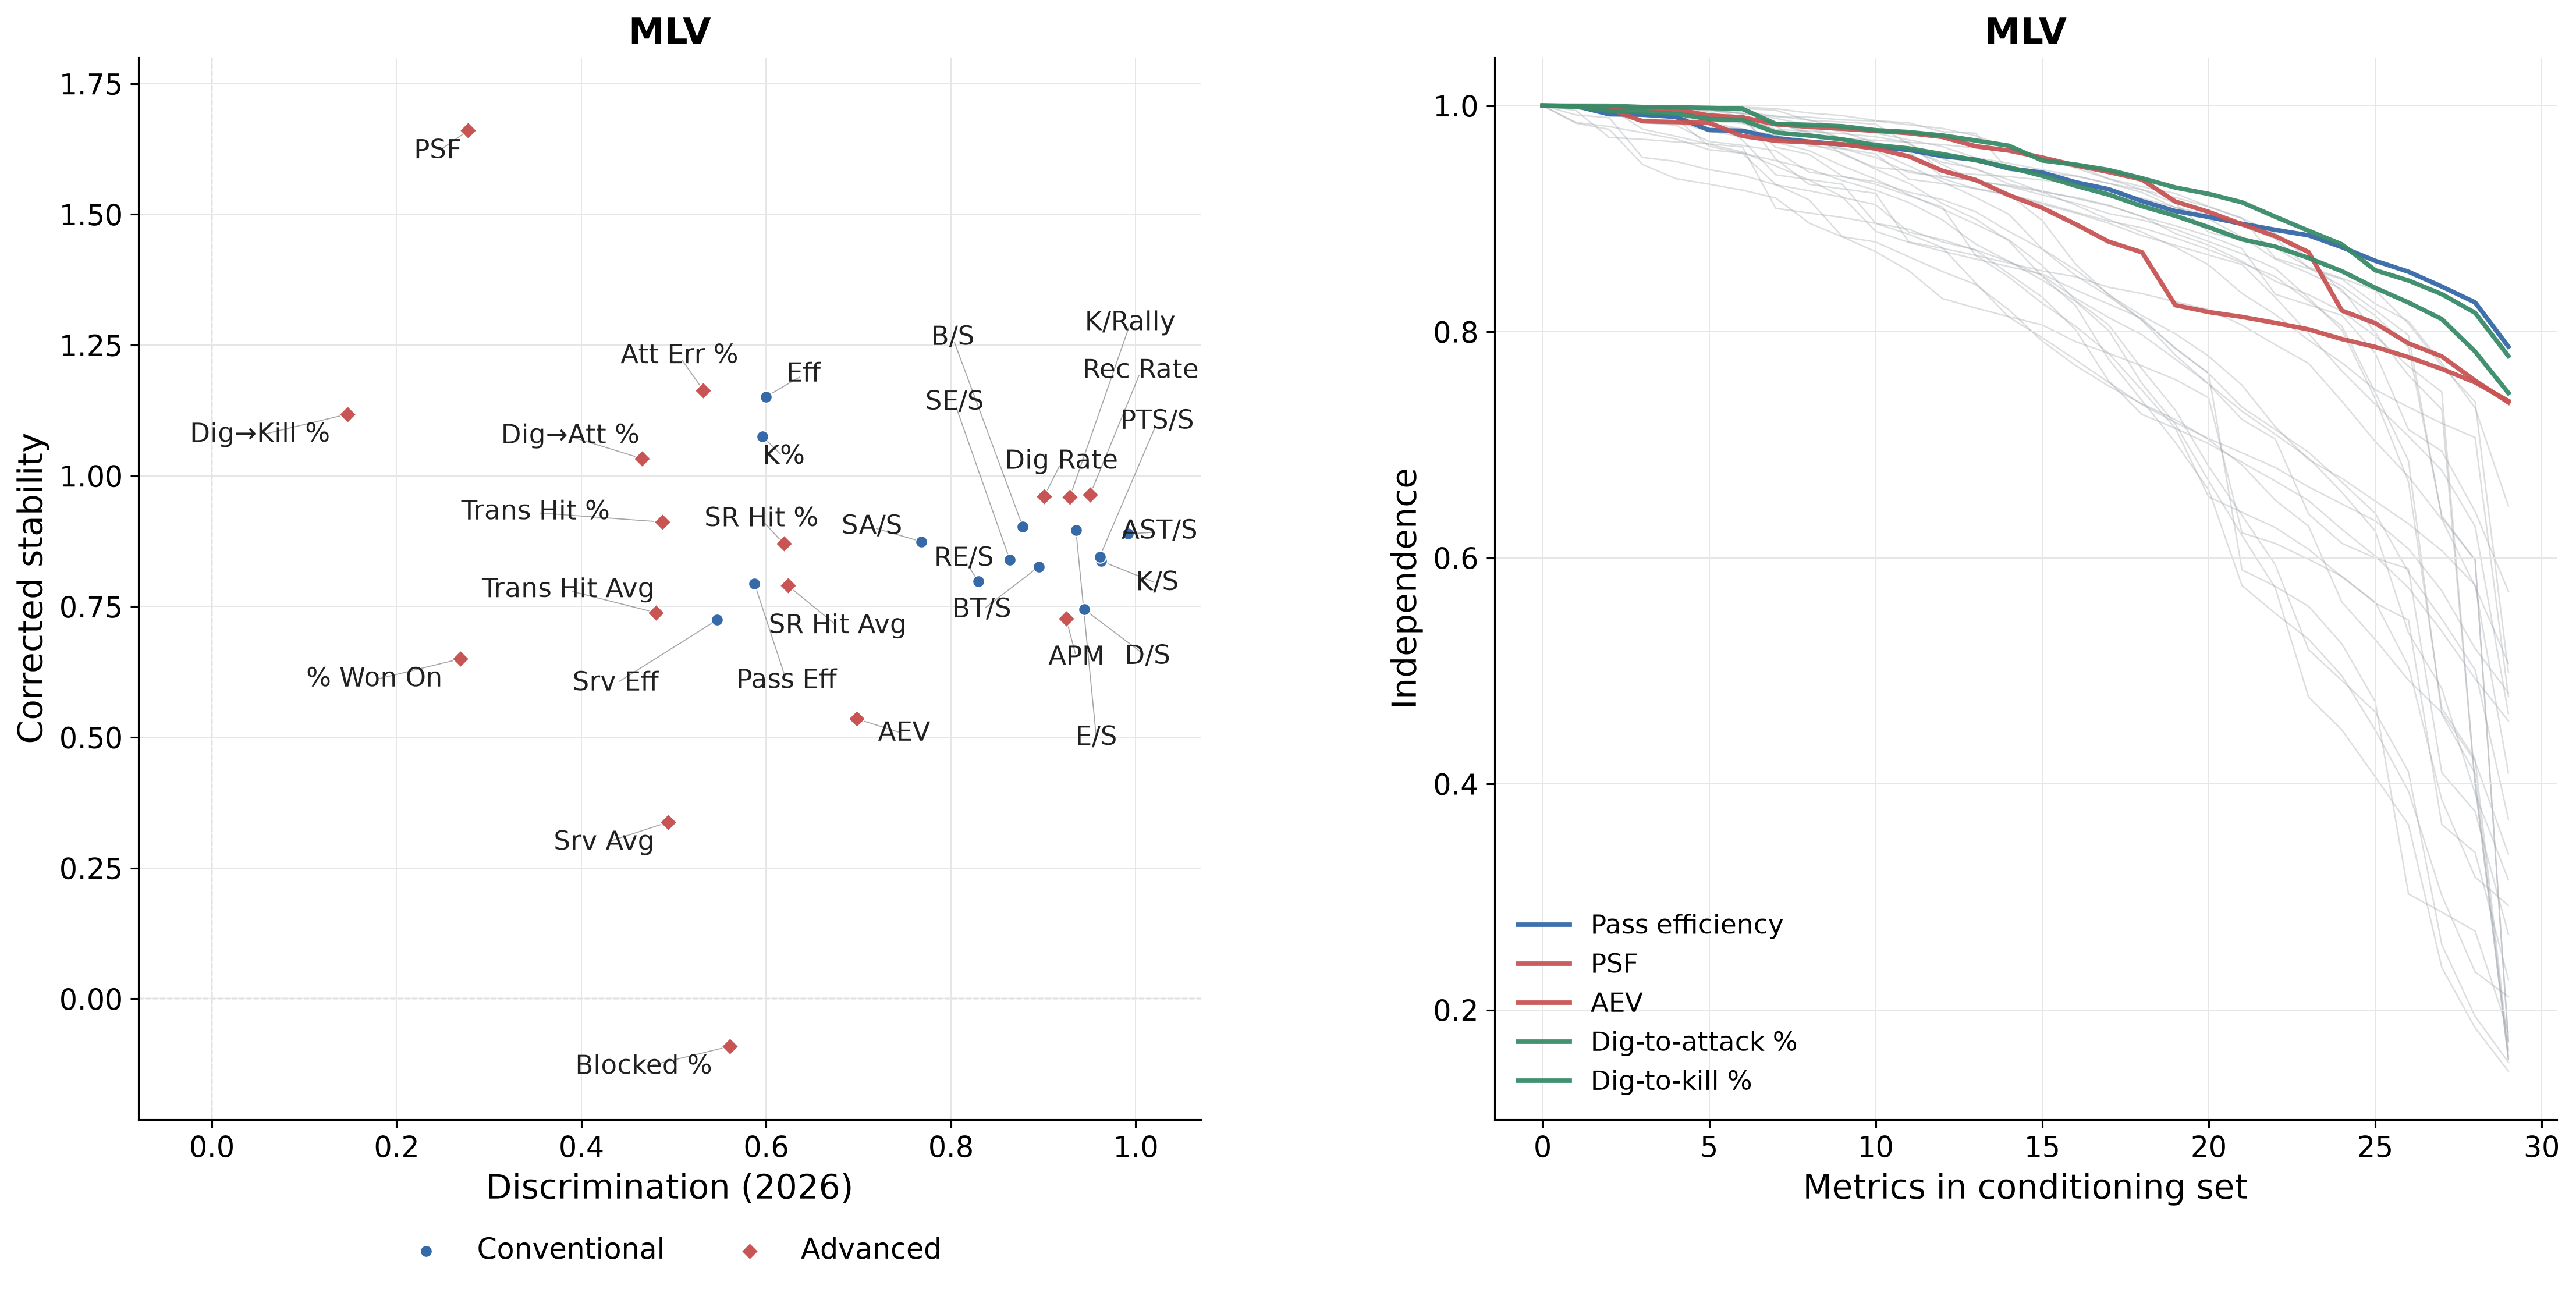

In [2]:
#| label: fig-meta-mlv
#| fig-cap: Meta-analytic results for MLV. The left panel shows latest-season discrimination and corrected stability, with estimates shown as calculated, including values outside the theoretical range. The right panel shows the greedy conditional-independence curves, with the five metrics having the largest full-conditioning independence values highlighted.
#| fig-align: center
fig = meta_figure("mlv")
plt.show()
plt.close(fig)

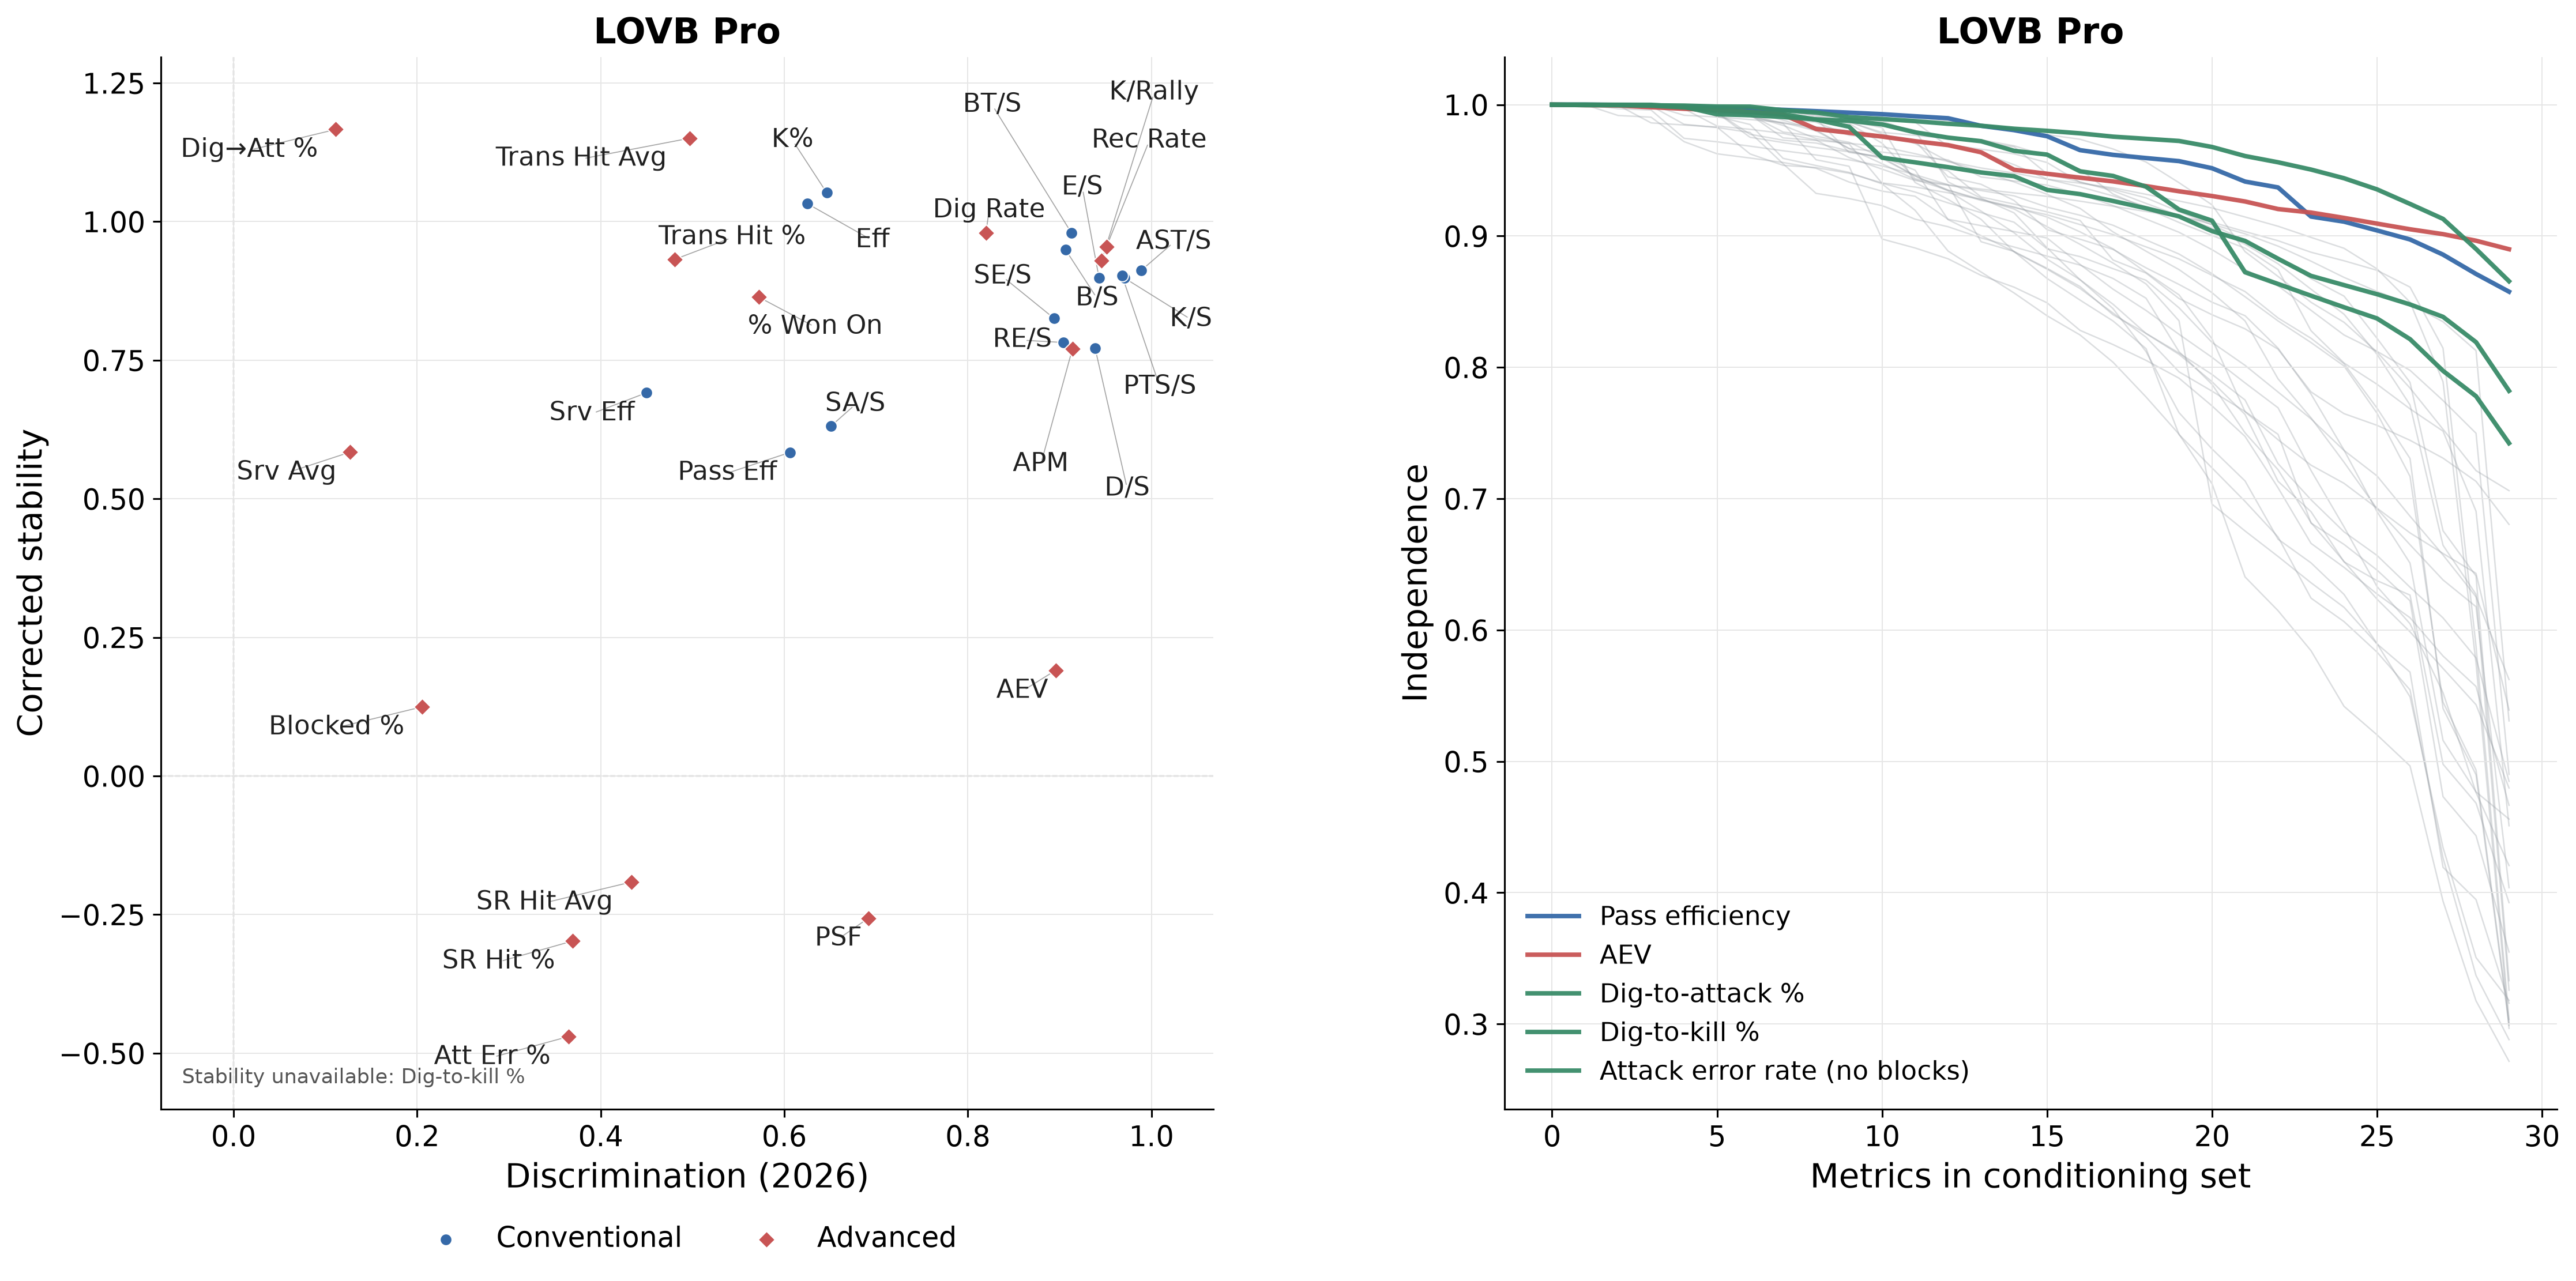

In [3]:
#| label: fig-meta-lovb
#| fig-cap: Meta-analytic results for LOVB Pro. The left panel shows latest-season discrimination and corrected stability, with estimates shown as calculated, including values outside the theoretical range. The right panel shows the greedy conditional-independence curves, with the five metrics having the largest full-conditioning independence values highlighted.
#| fig-align: center
fig = meta_figure("lovb")
plt.show()
plt.close(fig)

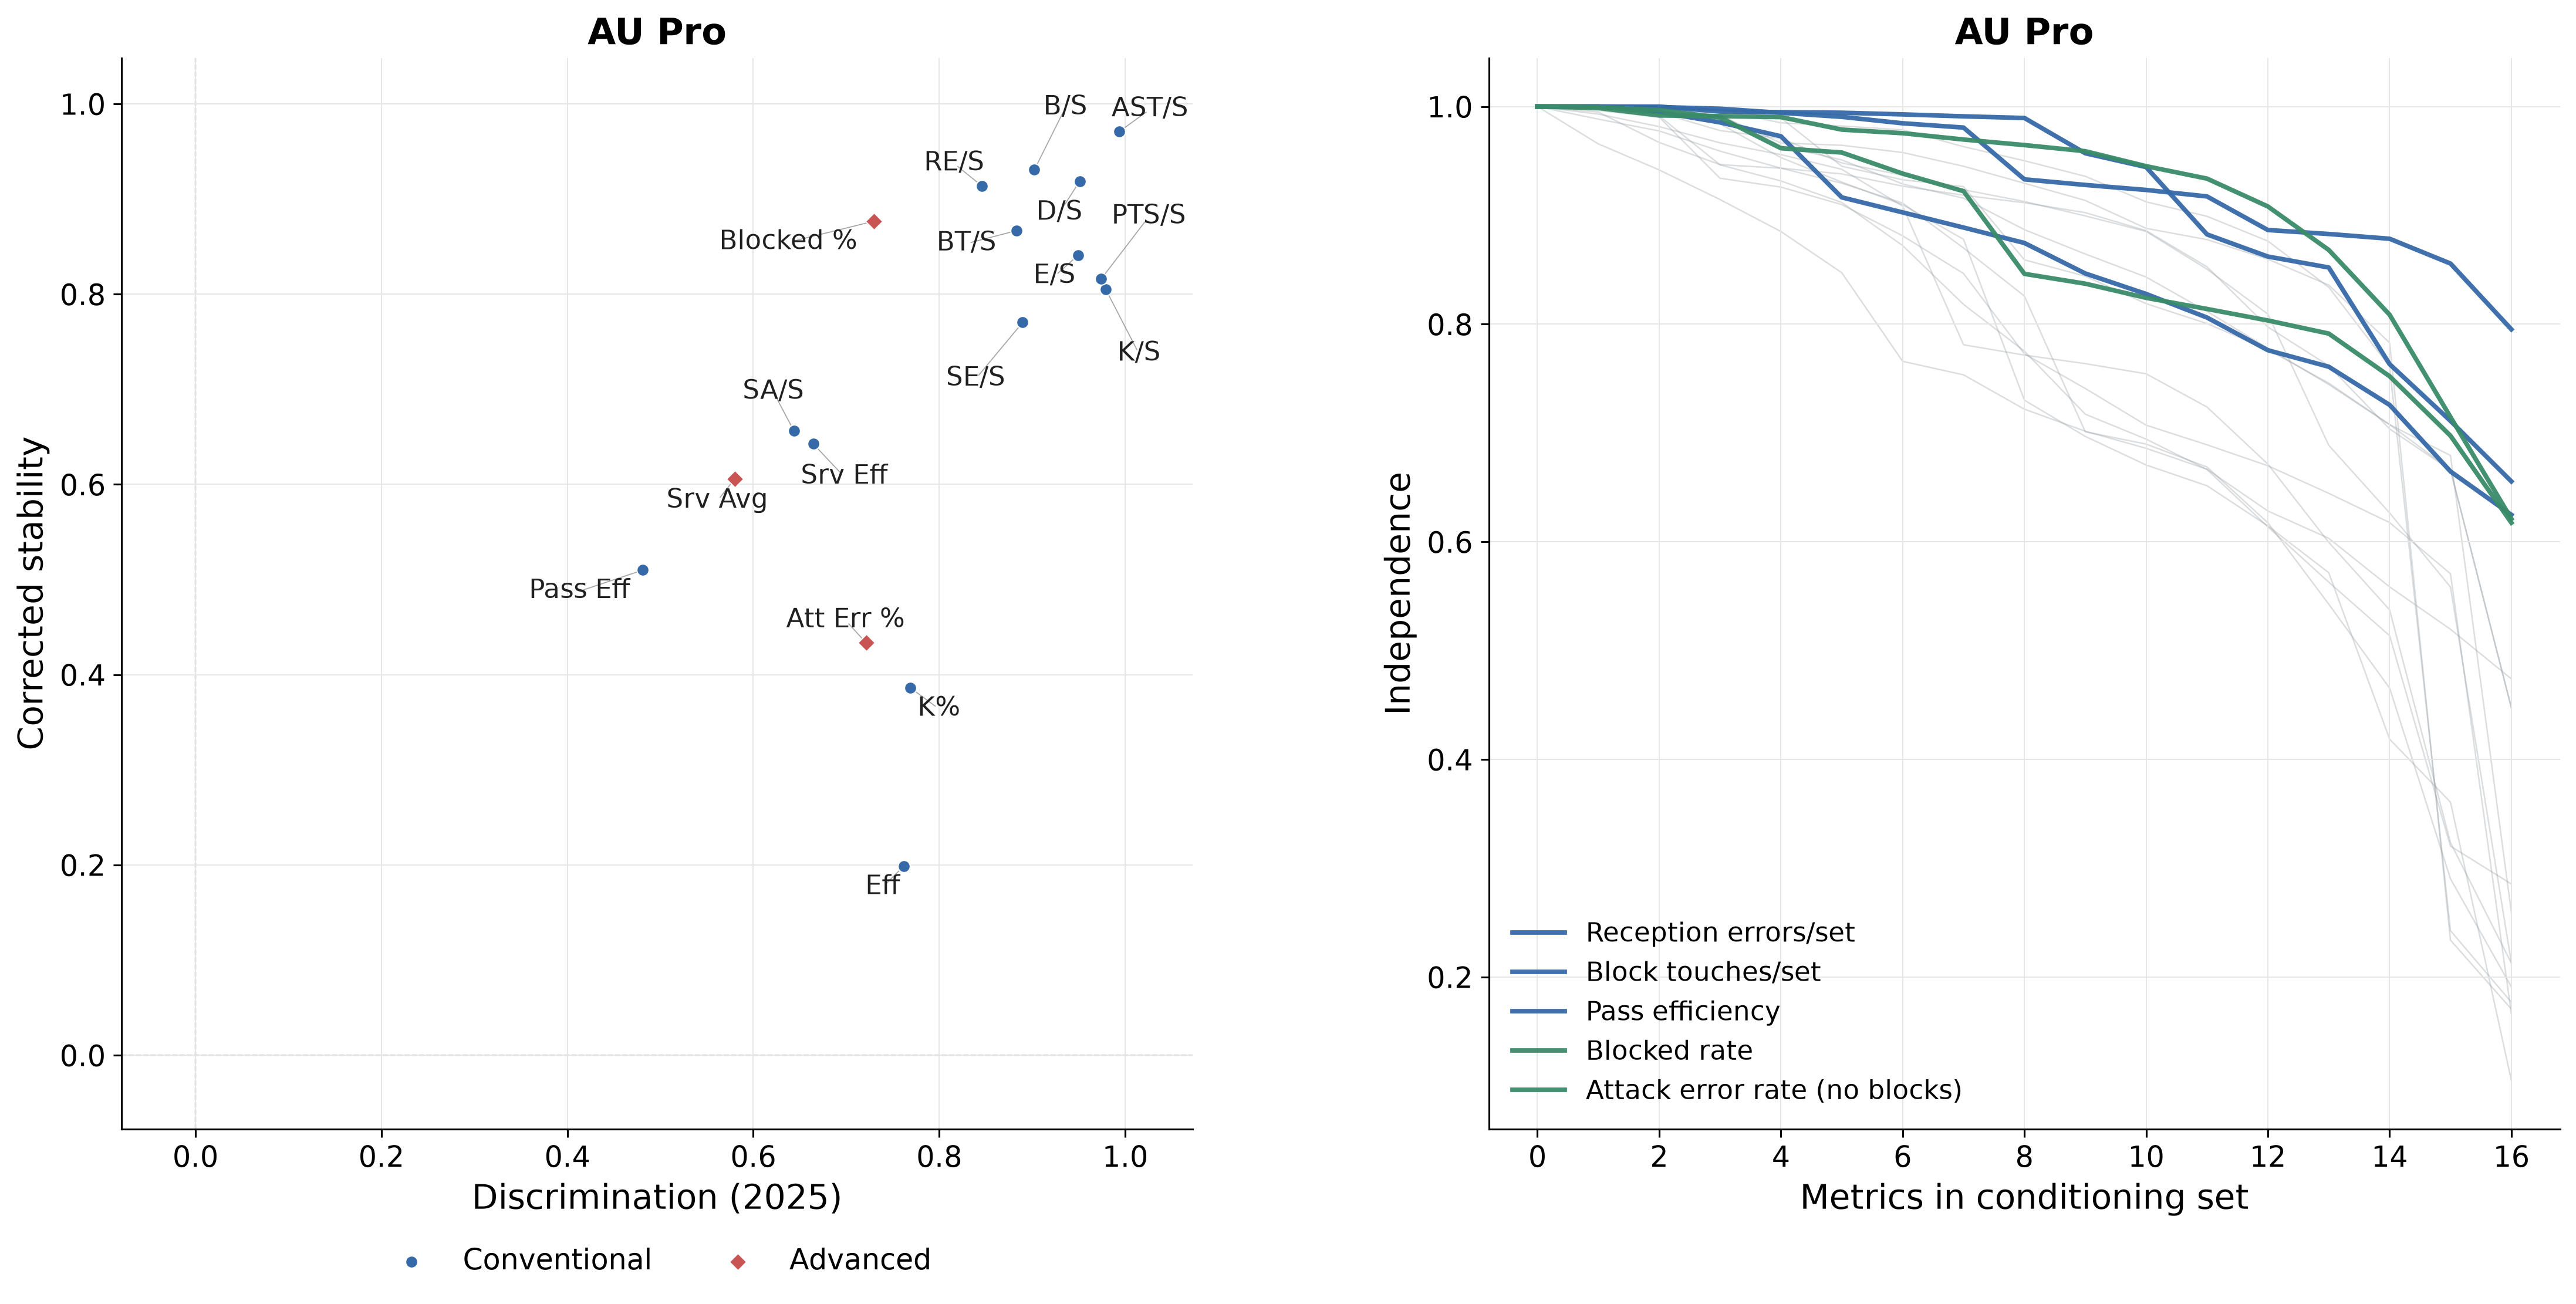

In [4]:
#| label: fig-meta-au
#| fig-cap: Meta-analytic results for AU Pro. The left panel shows latest-season discrimination and corrected stability. The right panel shows the greedy conditional-independence curves, with the five metrics having the largest full-conditioning independence values highlighted.
#| fig-align: center
fig = meta_figure("au")
plt.show()
plt.close(fig)

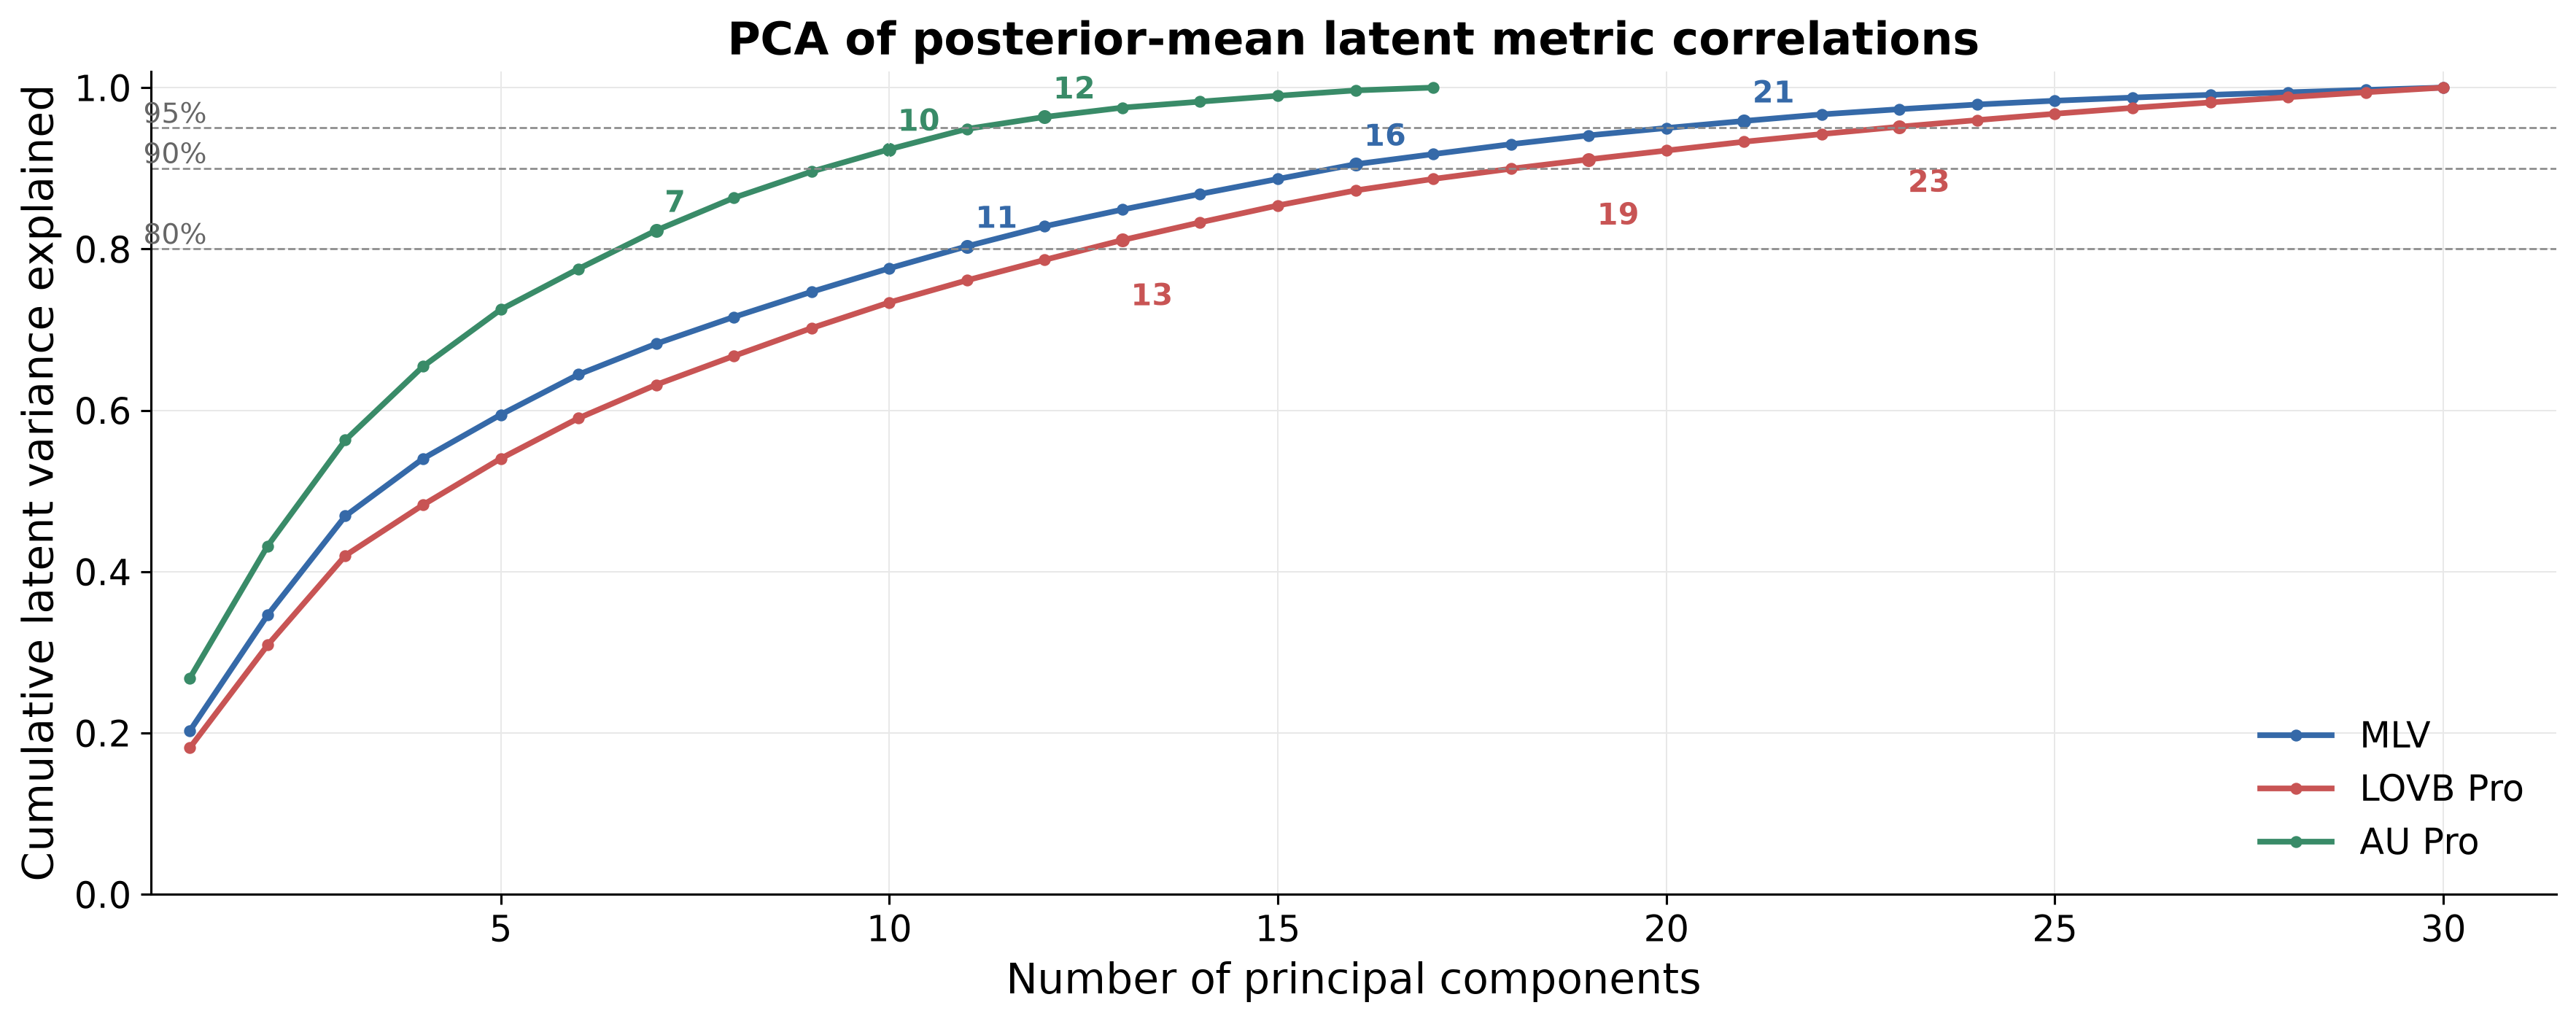

In [5]:
#| label: fig-pca
#| fig-cap: Cumulative variance explained by principal components of the posterior-mean latent correlation matrix for MLV, LOVB Pro, and AU Pro.
#| fig-align: center
fig = pca_figure()
plt.show()
plt.close(fig)

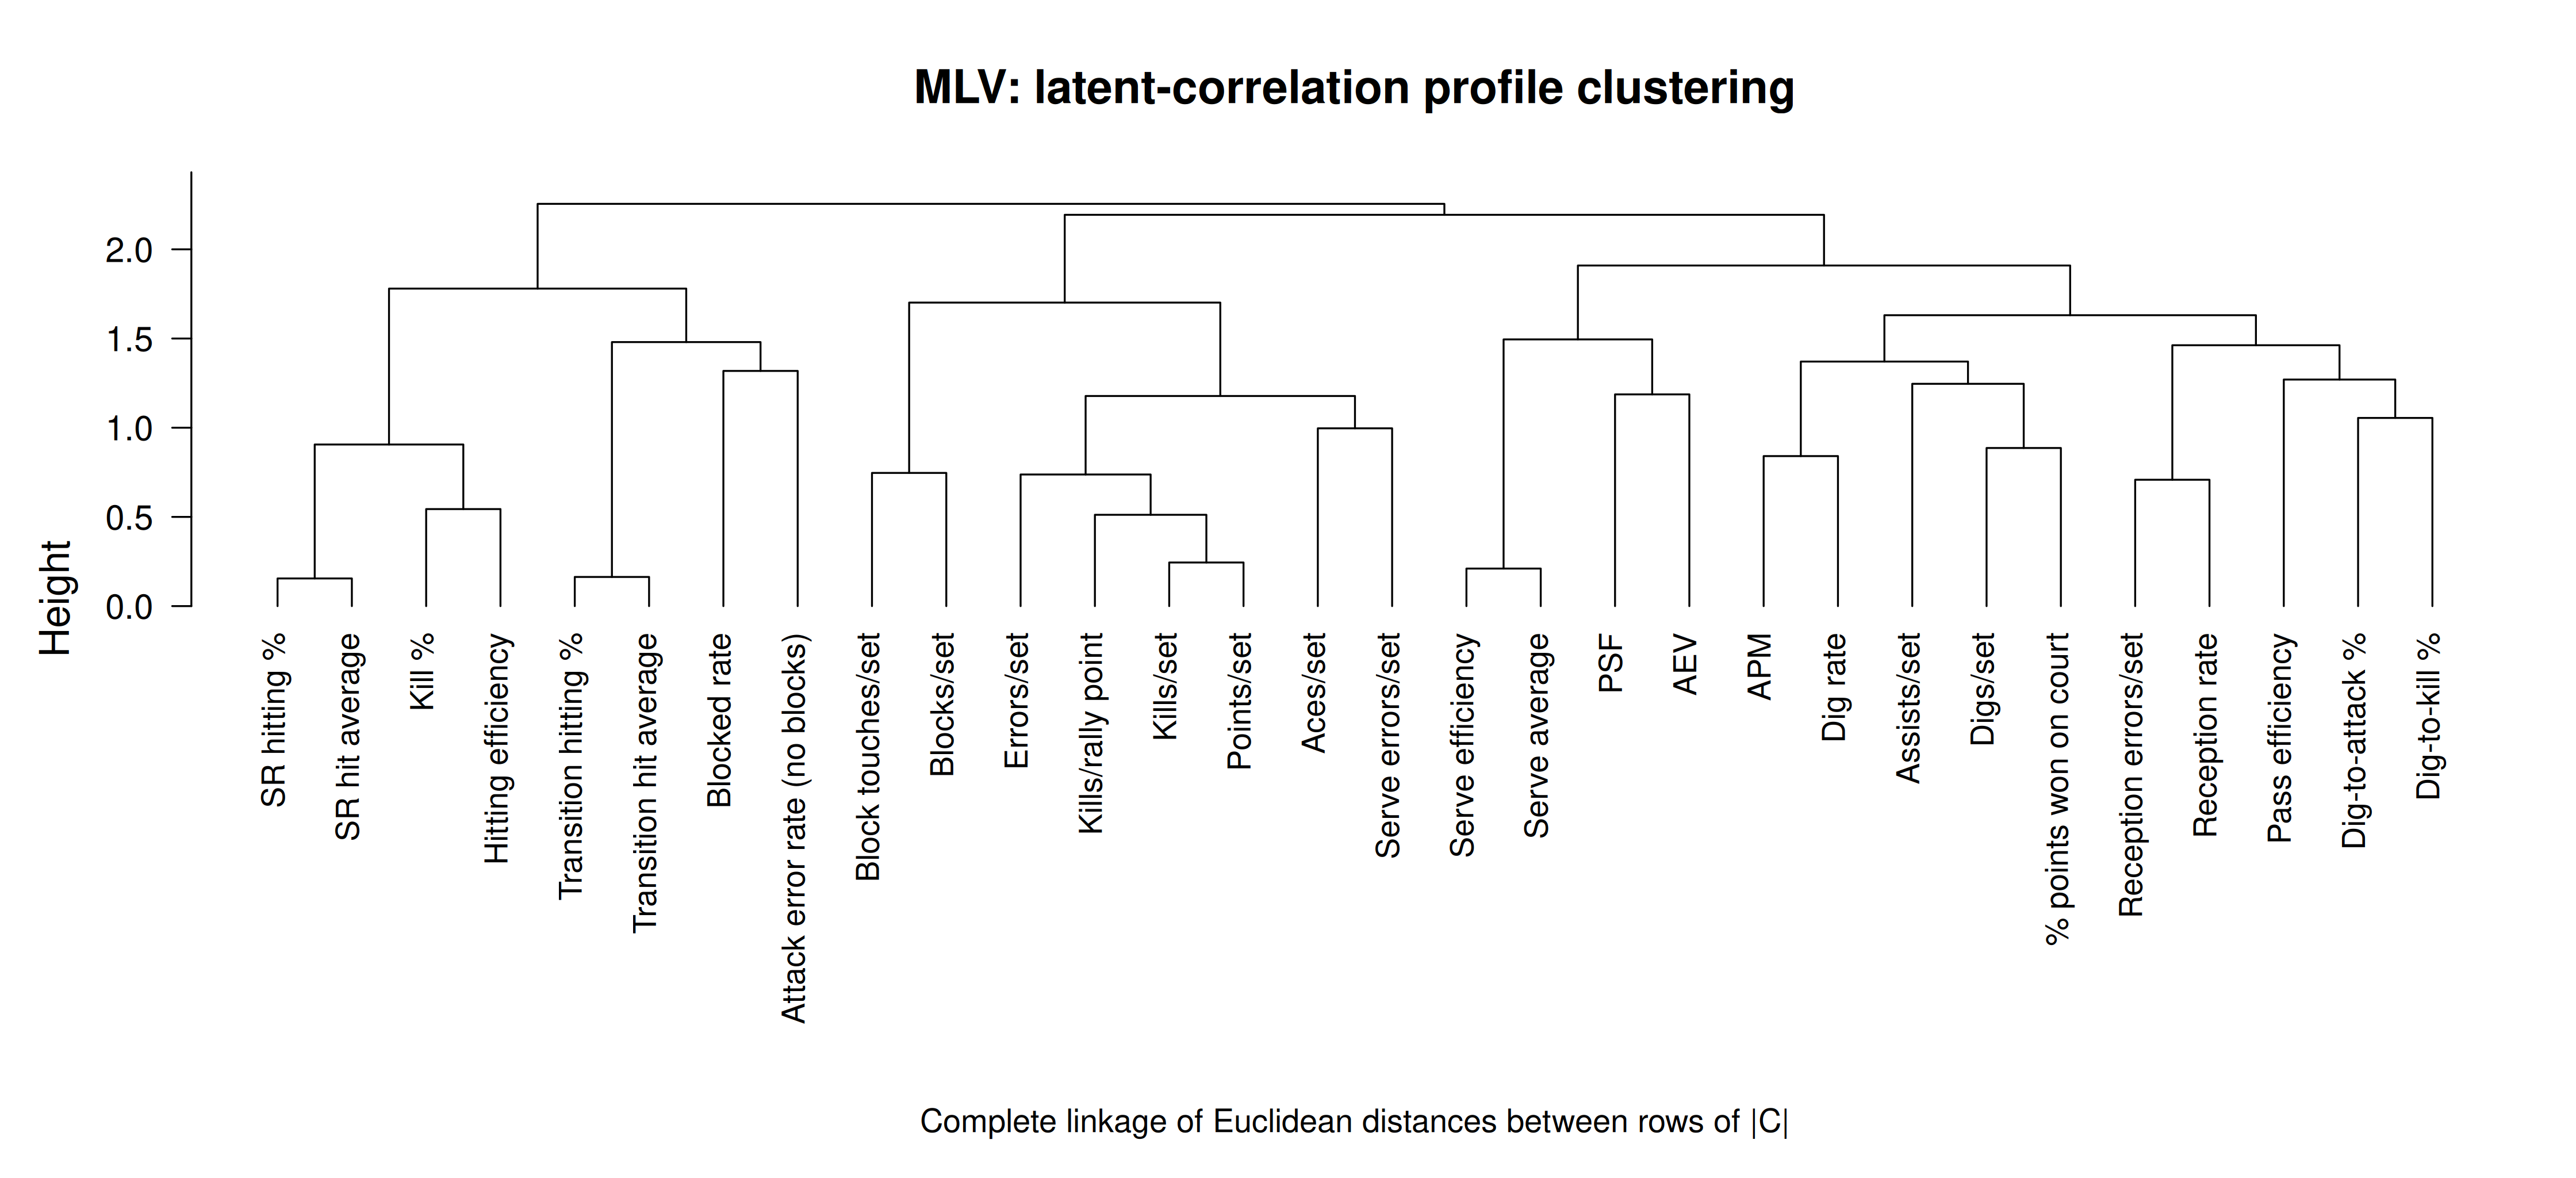

In [6]:
#| label: fig-clustering-mlv
#| fig-cap: Complete-linkage hierarchical clustering of metric correlation profiles for MLV. Distances are Euclidean distances between rows of the absolute posterior-mean latent correlation matrix.
#| fig-align: center
display(dendrogram_image("mlv"))

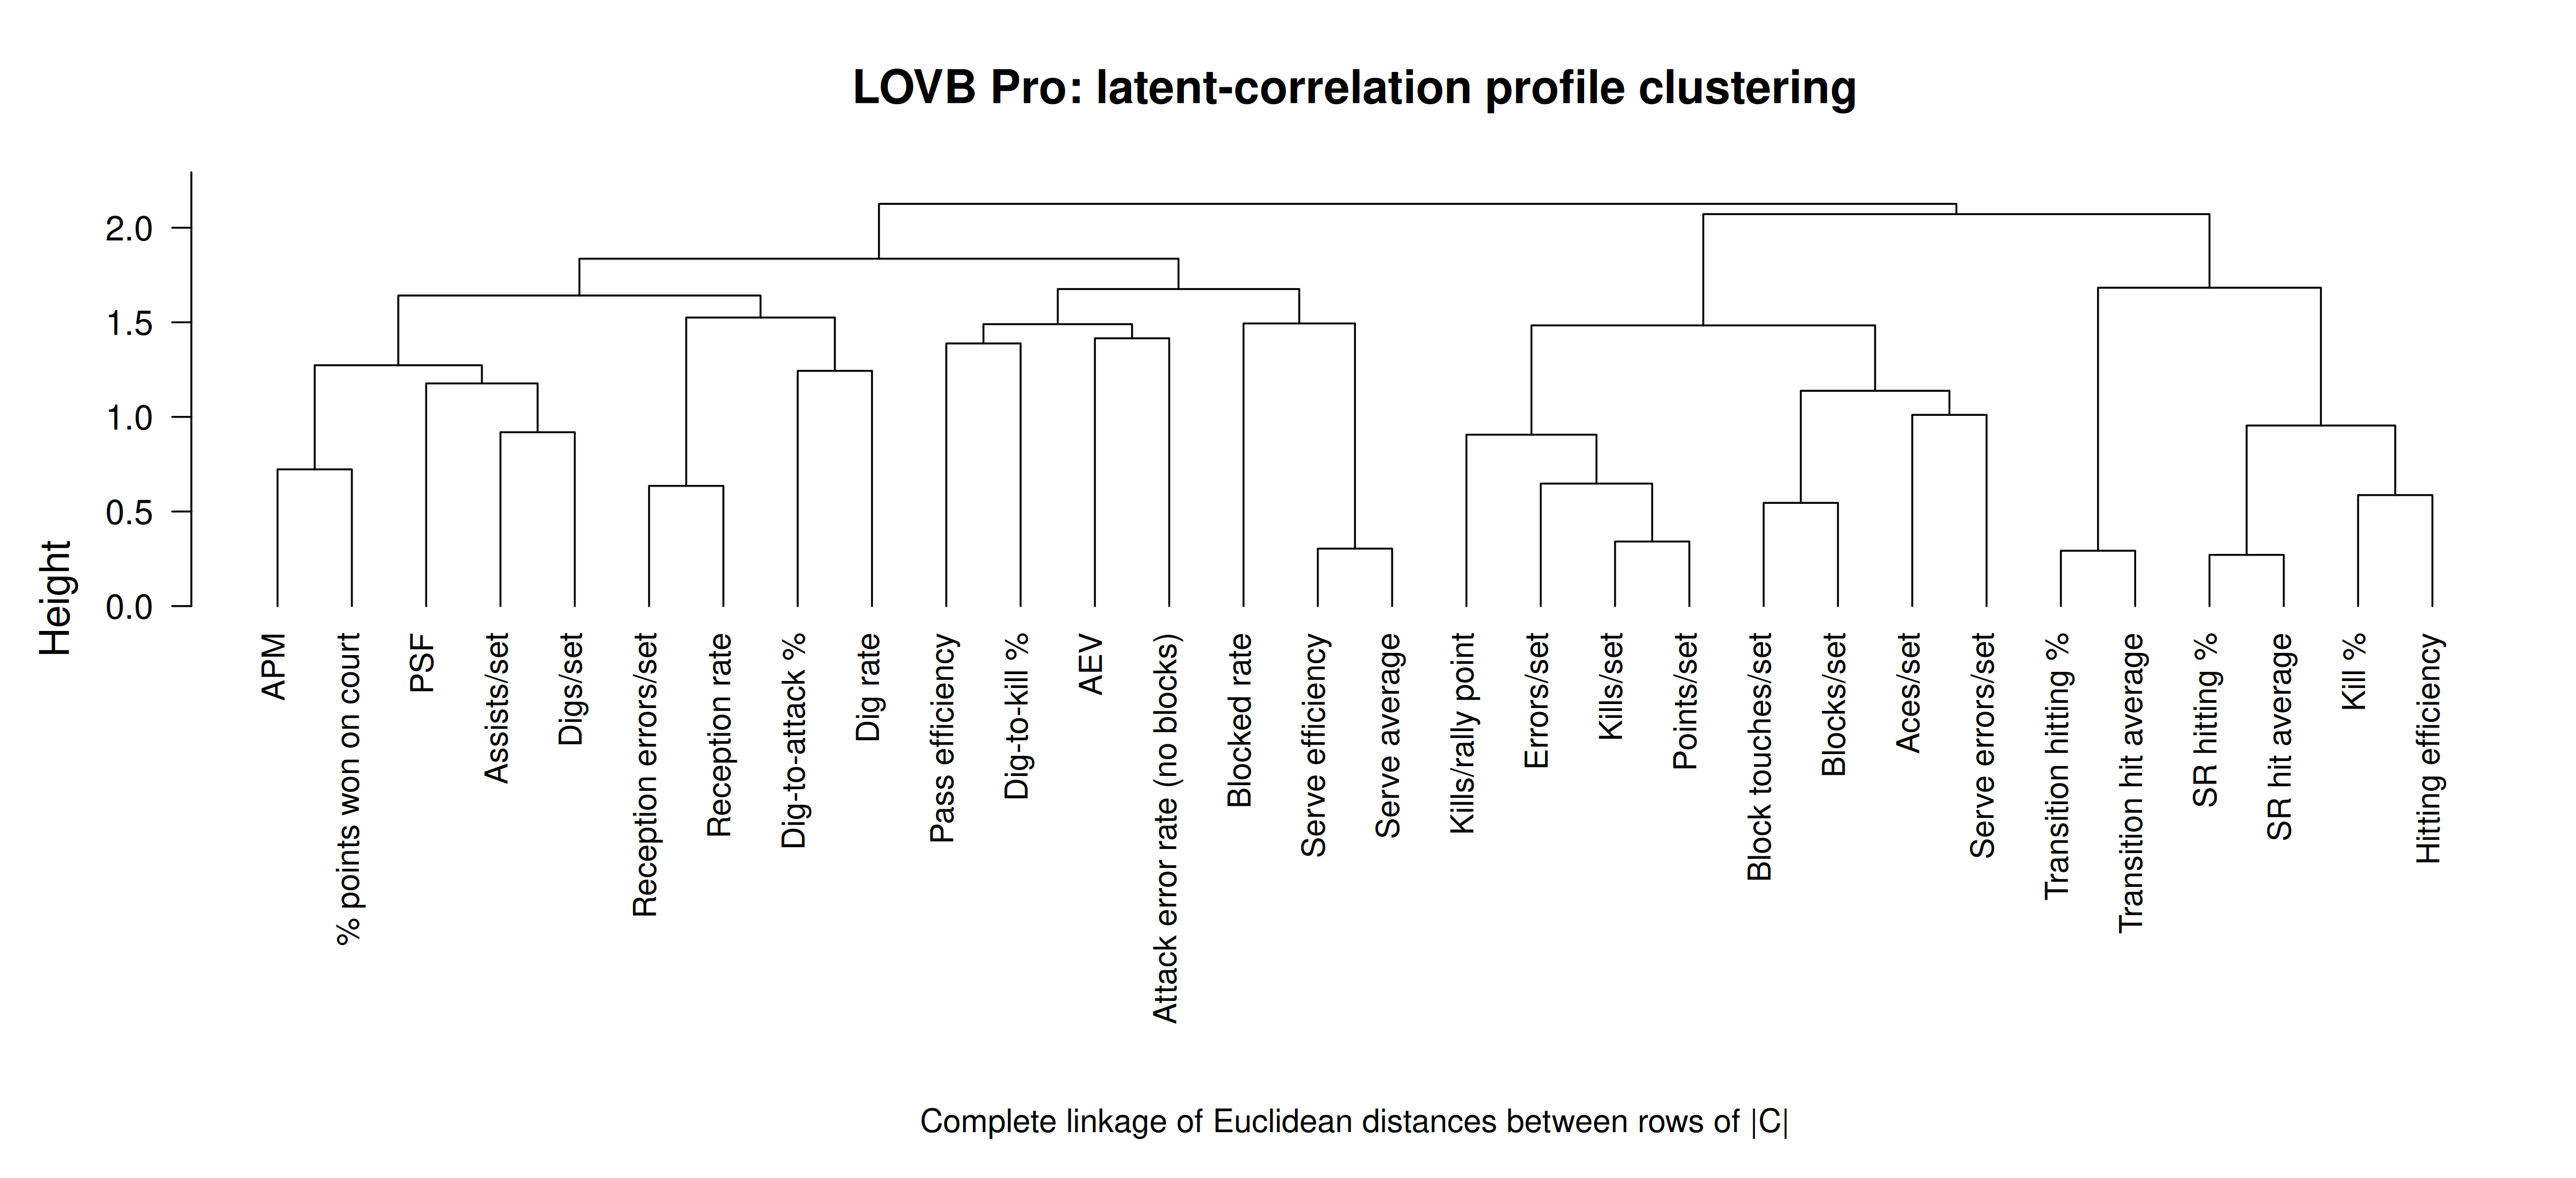

In [7]:
#| label: fig-clustering-lovb
#| fig-cap: Complete-linkage hierarchical clustering of metric correlation profiles for LOVB Pro. Distances are Euclidean distances between rows of the absolute posterior-mean latent correlation matrix.
#| fig-align: center
display(dendrogram_image("lovb"))

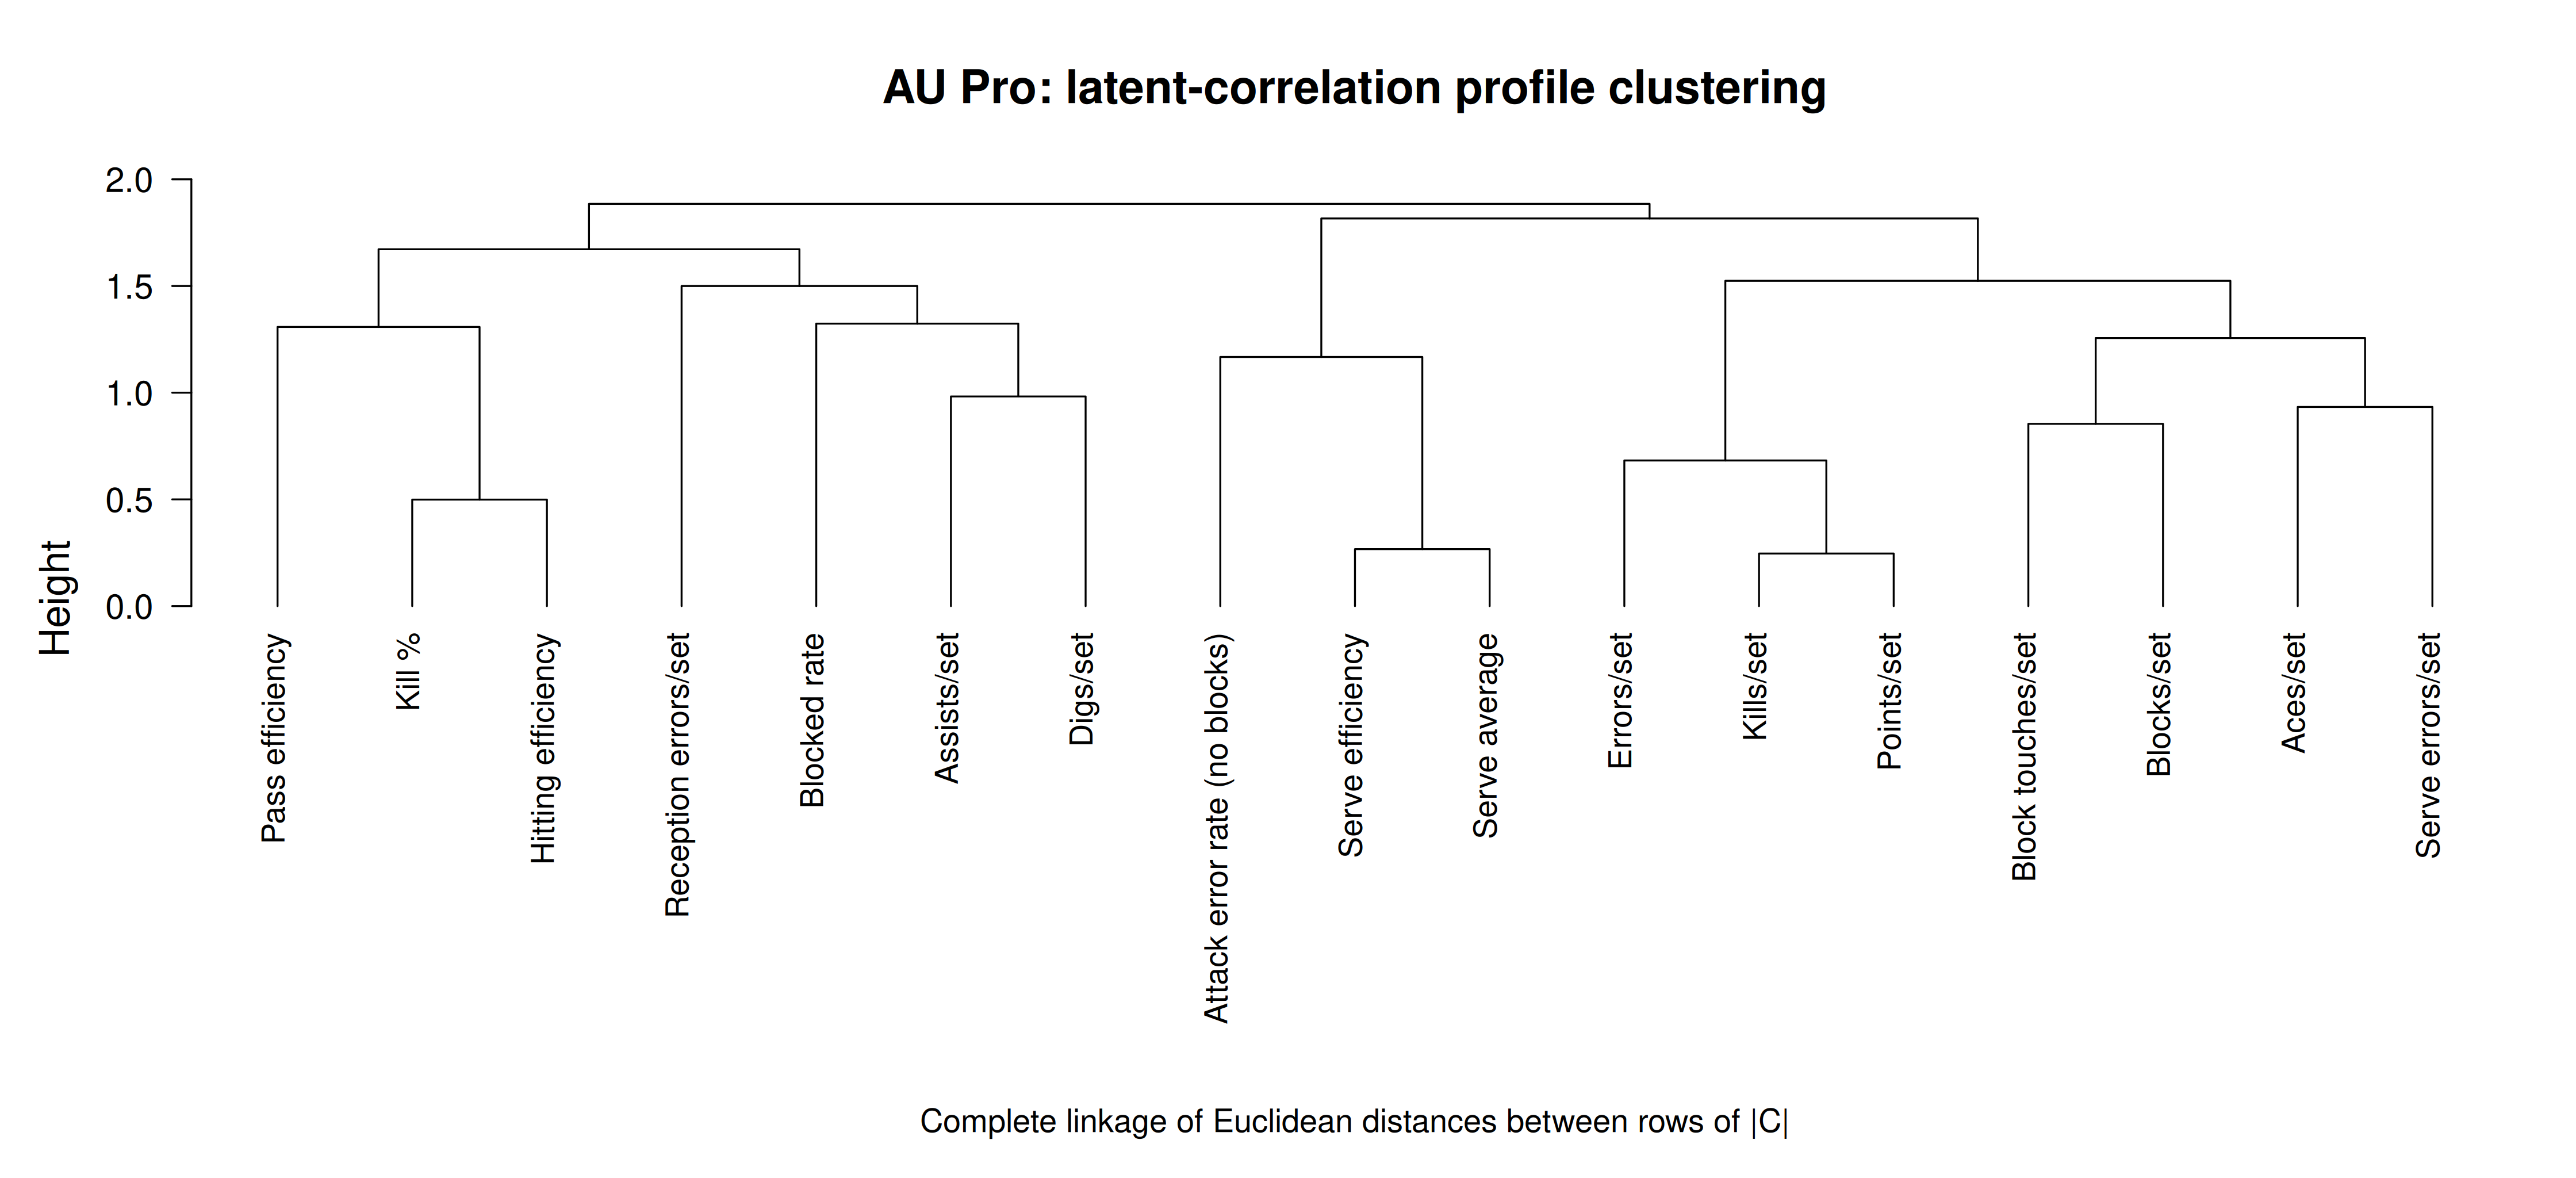

In [8]:
#| label: fig-clustering-au
#| fig-cap: Complete-linkage hierarchical clustering of metric correlation profiles for AU Pro. Distances are Euclidean distances between rows of the absolute posterior-mean latent correlation matrix.
#| fig-align: center
display(dendrogram_image("au"))